In [1]:
from utils import calculate_nse, create_lag, create_lag_adv, create_lag_adv_corrected

In [2]:
from shap import initjs


initjs()

In [3]:
#tips
#for single column dataframes always use double brackets, single brackets will make it a series, or float type
# for adding two columns to a df either add them one by one or use two brackets

In [4]:
import pandas as pd
df = pd.read_csv('final_data_physics_baseline/phy_final_corrected_data.csv')
pd.to_datetime(df['date'])
df = df.set_index('date')
df.drop(columns= 'Unnamed: 0', inplace= True)
df.drop(columns= 'Unnamed: 0.1', inplace= True)

# we convert 0-12 to radians circle for a seasonal mapping (circular time encoding)
# ensure index is treated as datetime (works even if the Index is not recognized as DatetimeIndex)
import numpy as np
month = pd.DatetimeIndex(df.index).month

df['year_sin'] = np.sin(2*np.pi*month/12)
df['year_cos'] = np.cos(2*np.pi*month/12)


df1 = df.copy()
df.head()


,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff,year_sin,year_cos
date,,,,,,,,,,,
2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,0.000000,255.924696,0.959289,1.224647e-16,-1.000000e+00
2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,0.000000,253.865719,0.515886,-5.000000e-01,-8.660254e-01
2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,0.000000,258.913569,0.355015,-8.660254e-01,-5.000000e-01
2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,0.000000,265.094486,0.186357,-1.000000e+00,-1.836970e-16
2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.551964,273.551964,0.138155,-8.660254e-01,5.000000e-01


In [5]:
# #WITHOUT SEASON AWARENESS
# #train baseline prediction regression model only fitted on train data
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression
# # lag_scaler = StandardScaler()


# x_lagged = create_lag(df1, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

# x_train = x_lagged[:'2017-12-31']
# x_val = x_lagged['2018-01-01':'2021-12-31']
# x_test = x_lagged['2022-01-01':]

# y_train = x_lagged[:'2017-12-31']
# y_val = x_lagged['2018-01-01':'2021-12-31']
# y_test = x_lagged['2022-01-01':]

# X_train_lagged = x_train[[ 'sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_train_lagged = y_train[['runoff']]
# Y_val_lagged = y_val[['runoff']]
# X_val_lagged = x_val[[ 'sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# X_test_lagged = x_test[['sca_lagged','dd_lagged','melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
# Y_test_lagged = x_test[['runoff']]

# X_train_val = pd.concat([X_train_lagged, X_val_lagged])
# Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
# x_lagged.head()
# # lag_scaler.fit(X_train_lagged)
 
# # x_train_scaled = lag_scaler.transform(X_train_lagged)
# # x_val_scaled = lag_scaler.transform(X_val_lagged)
# # x_test_scaled = lag_scaler.transform(X_test_lagged)

# model = LinearRegression()
# model.fit(X_train_lagged, Y_train_lagged)

# y_test_pred = model.predict(X_test_lagged)
# baseline_nse = calculate_nse(Y_test_lagged, y_test_pred)
# print(baseline_nse)
# # alpha, beta, gamma, delta=amodel.coef_
# print(model.coef_)

In [36]:
#train baseline prediction regression model only fitted on train data
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# lag_scaler = StandardScaler()


x_lagged = df1.copy()

x_t = x_lagged[:'2017-12-31']
x_v = x_lagged['2018-01-01':'2021-12-31']
x_te = x_lagged['2022-01-01':]

y_t = x_lagged[:'2017-12-31']
y_v = x_lagged['2018-01-01':'2021-12-31']
y_te = x_lagged['2022-01-01':]

x_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
x_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
x_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

y_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
y_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
y_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

X_train_lagged = x_train[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_train_lagged = y_train[['runoff']]
Y_val_lagged = y_val[['runoff']]
X_val_lagged = x_val[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
X_test_lagged = x_test[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_test_lagged = x_test[['runoff']]

X_train_val = pd.concat([X_train_lagged, X_val_lagged])
Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
x_lagged.head()
# lag_scaler.fit(X_train_lagged)
 
# x_train_scaled = lag_scaler.transform(X_train_lagged)
# x_val_scaled = lag_scaler.transform(X_val_lagged)
# x_test_scaled = lag_scaler.transform(X_test_lagged)
# x_val_lagged
Y_val_lagged.shape

/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:63: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:64: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

(45, 1)

In [ ]:
seasonaware_model = LinearRegression()
seasonaware_model.fit(X_train_lagged, Y_train_lagged)

y_val_pred = seasonaware_model.predict(X_val_lagged)
baseline_nse_val = calculate_nse(Y_val_lagged, y_test_pred)
print(baseline_nse_val)
# alpha, beta, gamma, delta=amodel.coef_
print(seasonaware_model.coef_)

In [6]:
#train baseline prediction regression model only fitted on train data
from re import X
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# lag_scaler = StandardScaler()


x_lagged = df1.copy()

x_t = x_lagged[:'2017-12-31']
x_v = x_lagged['2018-01-01':'2021-12-31']
x_te = x_lagged['2022-01-01':]

y_t = x_lagged[:'2017-12-31']
y_v = x_lagged['2018-01-01':'2021-12-31']
y_te = x_lagged['2022-01-01':]

x_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
x_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
x_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

y_train = create_lag(x_t, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
y_val = create_lag(x_v, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)
y_test = create_lag(x_te, lag_precip=1, lag_dd=3, lag_sca=3, lag_et=1)

X_train_lagged = x_train[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_train_lagged = y_train[['runoff']]
Y_val_lagged = y_val[['runoff']]
X_val_lagged = x_val[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
X_test_lagged = x_test[['sca_lagged','dd_lagged','year_sin', 'year_cos', 'melt_proxy', 'et_loss_lagged', 'precipitation_lagged']]
Y_test_lagged = x_test[['runoff']]

X_train_val = pd.concat([X_train_lagged, X_val_lagged])
Y_train_val = pd.concat([Y_train_lagged, Y_val_lagged])
x_lagged.head()
# lag_scaler.fit(X_train_lagged)
 
# x_train_scaled = lag_scaler.transform(X_train_lagged)
# x_val_scaled = lag_scaler.transform(X_val_lagged)
# x_test_scaled = lag_scaler.transform(X_test_lagged)

seasonaware_model = LinearRegression()
seasonaware_model.fit(X_train_lagged, Y_train_lagged)

y_test_pred = seasonaware_model.predict(X_test_lagged)
baseline_nse = calculate_nse(Y_test_lagged, y_test_pred)
print(baseline_nse)
# alpha, beta, gamma, delta=amodel.coef_
print(seasonaware_model.coef_)

runoff    0.684799
dtype: float64
[[ 2.16269601e-06 -1.27239269e-01  1.68094217e-01 -7.78212851e-01
   7.67360800e-08  5.11143655e+00 -1.17883239e-01]]


/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sca_lagged'] = df['sca'].shift(lag_sca)
/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dd_lagged'] = df['dd'].shift(lag_dd)
/Users/abhimanyu/Desktop/projects/the_indus_project/utils.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [7]:
train_preds = seasonaware_model.predict(X_train_lagged)
val_preds = seasonaware_model.predict(X_val_lagged)
test_preds = seasonaware_model.predict(X_test_lagged)

#recombination
baseline_q_no_leak = pd.concat([
    pd.DataFrame(train_preds, index=X_train_lagged.index, columns=['baseline_q']),
    pd.DataFrame(val_preds, index=X_val_lagged.index, columns=['baseline_q']),
    pd.DataFrame(test_preds, index=X_test_lagged.index, columns=['baseline_q'])
])
Y_full = pd.concat([Y_train_val, Y_test_lagged])

df_full = pd.concat([X_train_lagged, X_val_lagged, X_test_lagged])
df_full['baseline_q'] = baseline_q_no_leak
df_full['residuals'] = Y_full['runoff'] - df_full['baseline_q']

df_adv = create_lag_adv_corrected(df1) 
df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_


In [8]:
# from xgboost import XGBRegressor
# import pandas as pd

# xgb = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.01,
#     n_estimators=1500,
#     random_state=42, # Add for reproducibility
# )

# train_ml = df_adv[:'2017-12-31']
# val_ml = df_adv['2018-01-01':'2021-12-31']
# test_ml = df_adv['2022-01-01':]

# X_train_ml = train_ml.drop(columns=['baseline_q', 'residuals'])
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=['baseline_q', 'residuals'])
# y_val_ml = val_ml['residuals']

# # 4. Fit the model ONLY on the training data
# xgb.fit(X_train_ml, y_train_ml)

# # 5. Predict on the validation set
# residual_pred_val = xgb.predict(X_val_ml)
# q_hybrid_val = residual_pred_val + val_ml['baseline_q']

# # 6. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_val)

# print(f"Hybrid NSE (Validation): {hybrid_nse_val:.4f}")


In [9]:
# # --- Final Test Set Evaluation --- train model on train + val data

# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, y_val_ml])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=['baseline_q', 'residuals'])

# # Re-fit the model on all available training data
# xgb.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_test = xgb.predict(X_test_ml)
# q_hybrid_test = residual_pred_test + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_test)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [10]:

df_adv = create_lag_adv_corrected(df1) 
df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()
df_adv.head()
# df_adv['year_sin'] = x_lagged['year_sin']
# df_adv['year_cos'] = x_lagged['year_cos']
col_names = df_adv.columns.tolist()
col_names

['sca_lagged_1',
 'dd_lagged_1',
 'sca_lagged_2',
 'dd_lagged_2',
 'sca_lagged_3',
 'dd_lagged_3',
 'sca_lagged_4',
 'dd_lagged_4',
 'sca_lagged_5',
 'dd_lagged_5',
 'sca_lagged_6',
 'dd_lagged_6',
 'sca_lagged_7',
 'dd_lagged_7',
 'et_loss_lagged_1',
 'precipitation_lagged_1',
 'melt_proxy_1_1',
 'melt_proxy_2_1',
 'melt_proxy_2_2',
 'melt_proxy_3_2',
 'melt_proxy_3_3',
 'melt_proxy_4_3',
 'melt_proxy_4_4',
 'melt_proxy_5_4',
 'melt_proxy_5_5',
 'melt_proxy_6_5',
 'melt_proxy_6_6',
 'melt_proxy_7_6',
 'melt_proxy_7_7',
 'baseline_q',
 'residuals']

In [11]:

# df_adv = create_lag_adv_corrected(df1) 
# df_adv = df_adv.join(df_full[['baseline_q', 'residuals']]).dropna()
# from xgboost import XGBRegressor
# import pandas as pd

# # --- FIX: Explicitly define the feature set to exclude current-day data ---
# # These are the features created by create_lag_adv_corrected
# lagged_feature_columns = [
#     'sca_lagged_1', 'sca_lagged_2',
#     'dd_lagged_1', 'dd_lagged_2',
#     'et_loss_lagged_1',
#     'precipitation_lagged_1',
#     'melt_proxy_1_1', 'melt_proxy_1_2',
#     'melt_proxy_2_1', 'melt_proxy_2_2'
# ]

# # These are the columns we want to predict or use in the final calculation
# target_and_baseline_cols = ['baseline_q', 'residuals']

# # The final dataframe for the ML model should ONLY contain these columns
# df_ml_final = df_adv[lagged_feature_columns+ target_and_baseline_cols]


# # --- Now proceed with the corrected dataframe ---
# xgb1 = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.03,
#     n_estimators=1500,
#     random_state=42
# )

# # 1. Split the clean ML dataframe
# train_ml = df_ml_final[:'2017-12-31']
# val_ml = df_ml_final['2018-01-01':'2021-12-31']
# test_ml = df_ml_final['2022-01-01':]

# # 2. Prepare features and labels for validation
# X_train_ml = train_ml.drop(columns=target_and_baseline_cols)
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=target_and_baseline_cols)

# # 3. Fit the model ONLY on the training data
# xgb1.fit(X_train_ml, y_train_ml)

# # 4. Predict on the validation set
# residual_pred_val = xgb1.predict(X_val_ml)
# q_hybrid_val = residual_pred_val + val_ml['baseline_q']

# # 5. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_val)

# print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# # --- Final Test Set Evaluation ---
# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals']])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# # Re-fit the model on all available training data
# xgb1.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_test = xgb1.predict(X_test_ml)
# q_hybrid_test = residual_pred_test + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_test)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [12]:
df_features = df_adv.drop(columns=['residuals', 'baseline_q'])
df_features.head()

,sca_lagged_1,dd_lagged_1,sca_lagged_2,dd_lagged_2,sca_lagged_3,dd_lagged_3,sca_lagged_4,dd_lagged_4,sca_lagged_5,dd_lagged_5,...,melt_proxy_3_2,melt_proxy_3_3,melt_proxy_4_3,melt_proxy_4_4,melt_proxy_5_4,melt_proxy_5_5,melt_proxy_6_5,melt_proxy_6_6,melt_proxy_7_6,melt_proxy_7_7
date,,,,,,,,,,,,,,,,,,,,,
2001-01-31,36902.800385,9.535170,21183.674218,5.271130,19583.623736,0.551964,12888.810599,0.000000,10114.130241,0.000000,...,103227.834953,10809.451022,7114.156644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2001-02-28,35286.368770,7.745643,36902.800385,9.535170,21183.674218,5.271130,19583.623736,0.551964,12888.810599,0.000000,...,201989.936303,111661.909735,103227.834953,10809.451022,7114.156644,0.000000,0.000000,0.000000,0.000000,0.000000
2001-03-31,25131.303245,3.499669,35286.368770,7.745643,36902.800385,9.535170,21183.674218,5.271130,19583.623736,0.551964,...,285835.917089,351874.477600,201989.936303,111661.909735,103227.834953,10809.451022,7114.156644,0.000000,0.000000,0.000000
2001-04-30,46124.160931,0.000000,25131.303245,3.499669,35286.368770,7.745643,36902.800385,9.535170,21183.674218,5.271130,...,123490.610497,273315.614884,285835.917089,351874.477600,201989.936303,111661.909735,103227.834953,10809.451022,7114.156644,0.000000
2001-05-31,34841.225052,0.000000,46124.160931,0.000000,25131.303245,3.499669,35286.368770,7.745643,36902.800385,9.535170,...,0.000000,87951.242605,123490.610497,273315.614884,285835.917089,351874.477600,201989.936303,111661.909735,103227.834953,10809.451022


In [13]:

# from xgboost import XGBRegressor
# import pandas as pd

# # --- FIX: Explicitly define the feature set to exclude current-day data ---
# # These are the features created by create_lag_adv_corrected
# lagged_feature_columns =[
#  'et_loss_lagged_1',
#  'precipitation_lagged_1',
#  'melt_proxy_1_1',
#  'melt_proxy_2_1',
#  'melt_proxy_2_2',
#  'melt_proxy_3_2',
#  'melt_proxy_3_3',
#  'melt_proxy_4_3',
#  'melt_proxy_4_4',
#  'melt_proxy_5_4',
#  'melt_proxy_5_5',
#  'melt_proxy_6_5',
#  'melt_proxy_6_6',
#  'melt_proxy_7_6',
#  'melt_proxy_7_7',
#  'baseline_q',
#  'residuals',
# ]

# # These are the columns we want to predict or use in the final calculation
# target_and_baseline_cols = ['baseline_q', 'residuals']

# # The final dataframe for the ML model should ONLY contain these columns
# df_ml_final = df_adv[lagged_feature_columns]


# # --- Now proceed with the corrected dataframe ---
# xgb1 = XGBRegressor(
#     max_depth=5,
#     learning_rate=0.01,
#     n_estimators=1500,
#     random_state=42
# )

# # 1. Split the clean ML dataframe
# train_ml = df_ml_final[:'2017-12-31']
# val_ml = df_ml_final['2018-01-01':'2021-12-31']
# test_ml = df_ml_final['2022-01-01':]

# # 2. Prepare features and labels for validation
# X_train_ml = train_ml.drop(columns=target_and_baseline_cols)
# y_train_ml = train_ml['residuals']

# X_val_ml = val_ml.drop(columns=target_and_baseline_cols)

# # 3. Fit the model ONLY on the training data
# xgb1.fit(X_train_ml, y_train_ml)

# # 4. Predict on the validation set
# residual_pred_valf = xgb1.predict(X_val_ml)
# q_hybrid_valf = residual_pred_valf + val_ml['baseline_q']

# # 5. Evaluate against the correct validation ground truth
# y_val_true = Y_full['runoff'].loc[val_ml.index]
# hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_valf)

# print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# # --- Final Test Set Evaluation ---
# # Prepare combined training/validation data
# X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
# y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals']])

# # Prepare test data
# X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# # Re-fit the model on all available training data
# xgb1.fit(X_train_val_ml, y_train_val_ml)

# # Predict on the test set
# residual_pred_testf = xgb1.predict(X_test_ml)
# q_hybrid_testf = residual_pred_testf + test_ml['baseline_q']

# # Evaluate against the test ground truth
# y_test_true = Y_full['runoff'].loc[test_ml.index]
# hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_testf)

# print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

In [ ]:

from xgboost import XGBRegressor
import pandas as pd

# --- FIX: Explicitly define the feature set to exclude current-day data ---
# These are the features created by create_lag_adv_corrected
lagged_feature_columns =[
 'sca_lagged_1',
 'dd_lagged_1',
 'sca_lagged_2',
 'dd_lagged_2',
 'sca_lagged_3',
 'dd_lagged_3',
 'sca_lagged_4',
 'dd_lagged_4',
 'sca_lagged_5',
 'dd_lagged_5',
 'sca_lagged_6',
 'dd_lagged_6',
 'sca_lagged_7',
 'dd_lagged_7',
 'et_loss_lagged_1',
 'precipitation_lagged_1',
 'melt_proxy_1_1',
 'melt_proxy_2_1',
 'melt_proxy_2_2',
 'melt_proxy_3_2',
 'melt_proxy_3_3',
 'melt_proxy_4_3',
 'melt_proxy_4_4',
 'melt_proxy_5_4',
 'melt_proxy_5_5',
 'melt_proxy_6_5',
 'melt_proxy_6_6',
 'melt_proxy_7_6',
 'melt_proxy_7_7',
 'baseline_q',
 'residuals',
]

# These are the columns we want to predict or use in the final calculation
target_and_baseline_cols = ['baseline_q', 'residuals']

 # The final dataframe for the ML model should ONLY contain these columns
df_ml_final = df_adv[lagged_feature_columns]


# --- Now proceed with the corrected dataframe ---
xgb2 = XGBRegressor(
    max_depth=3,
    learning_rate=0.01,
    n_estimators=1000,
    random_state=42
)

# 1. Split the clean ML dataframe
train_ml = df_ml_final[:'2017-12-31']
val_ml = df_ml_final['2018-01-01':'2021-12-31']
test_ml = df_ml_final['2022-01-01':]

# 2. Prepare features and labels for validation
X_train_ml = train_ml.drop(columns=target_and_baseline_cols)
y_train_ml = train_ml['residuals']

X_val_ml = val_ml.drop(columns=target_and_baseline_cols)

# 3. Fit the model ONLY on the training data
xgb2.fit(X_train_ml, y_train_ml)

# 4. Predict on the validation set
residual_pred_valf = xgb2.predict(X_val_ml)
q_hybrid_valf = residual_pred_valf + val_ml['baseline_q']

# 5. Evaluate against the correct validation ground truth
y_val_true = Y_full['runoff'].loc[val_ml.index]
hybrid_nse_val = calculate_nse(y_val_true, q_hybrid_valf)

print(f"Corrected Hybrid NSE (Validation): {hybrid_nse_val:.4f}")

# --- Final Test Set Evaluation ---
# Prepare combined training/validation data
X_train_val_ml = pd.concat([X_train_ml, X_val_ml])
y_train_val_ml = pd.concat([y_train_ml, val_ml['residuals']])

# Prepare test data
X_test_ml = test_ml.drop(columns=target_and_baseline_cols)

# Re-fit the model on all available training data
xgb2.fit(X_train_val_ml, y_train_val_ml)

# Predict on the test set
residual_pred_testf = xgb2.predict(X_test_ml)
q_hybrid_testf = residual_pred_testf + test_ml['baseline_q']

# Evaluate against the test ground truth
y_test_true = Y_full['runoff'].loc[test_ml.index]
hybrid_nse_test = calculate_nse(y_test_true, q_hybrid_testf)

print(f"Final Hybrid NSE (Test): {hybrid_nse_test:.4f}")

Corrected Hybrid NSE (Validation): 0.7336
Final Hybrid NSE (Test): 0.7052
Final Hybrid NSE (Test): 0.7052


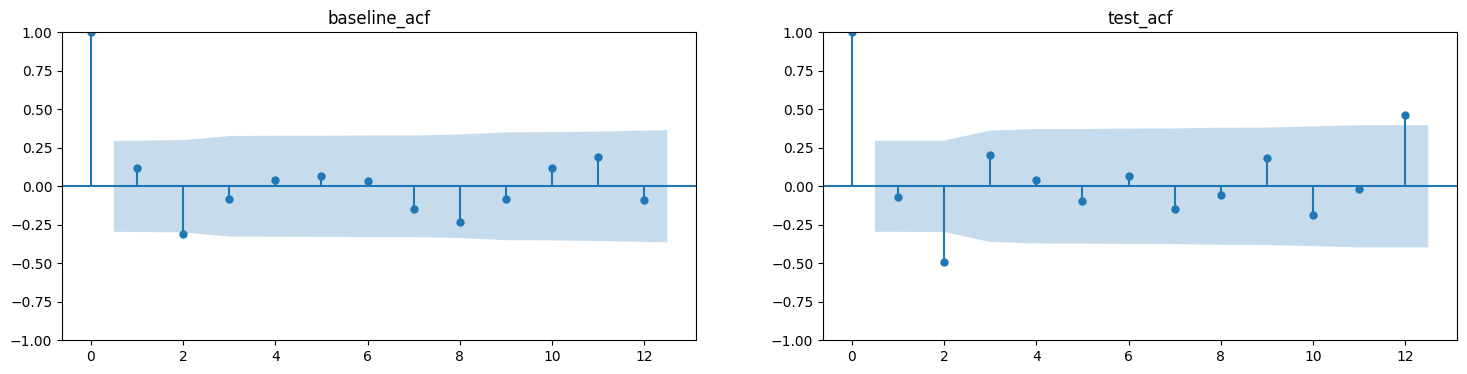

Durbin-Watson — Baseline: 1.753 | Hybrid: 2.046


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1,2, figsize= (18, 4))
# plot_acf( residual_pred_valf, lags = 12, ax = axes[0], title = 'val_acf' )
plot_acf( test_ml['residuals'], lags = 12, ax = axes[0], title = 'baseline_acf' )
plot_acf(residual_pred_testf, lags=12, ax=axes[1], title='test_acf')

plt.savefig('acf_residuals.png', dpi=150)
plt.show()

# 2. Durbin-Watson statistic (quick scalar check)
dw_baseline = durbin_watson(test_ml['residuals'])
dw_hybrid   = durbin_watson(residual_pred_testf)

print(f"Durbin-Watson — Baseline: {dw_baseline:.3f} | Hybrid: {dw_hybrid:.3f}")
# ~2.0 = no autocorrelation, <1.5 = positive autocorrelation (bad), >2.5 = negative


In [16]:
# print(X_val_ml.iloc[0])
# print(val_ml['residuals'].iloc[0])
val_ml.count()

sca_lagged_1              45
dd_lagged_1               45
sca_lagged_2              45
dd_lagged_2               45
sca_lagged_3              45
dd_lagged_3               45
sca_lagged_4              45
dd_lagged_4               45
sca_lagged_5              45
dd_lagged_5               45
sca_lagged_6              45
dd_lagged_6               45
sca_lagged_7              45
dd_lagged_7               45
et_loss_lagged_1          45
precipitation_lagged_1    45
melt_proxy_1_1            45
melt_proxy_2_1            45
melt_proxy_2_2            45
melt_proxy_3_2            45
melt_proxy_3_3            45
melt_proxy_4_3            45
melt_proxy_4_4            45
melt_proxy_5_4            45
melt_proxy_5_5            45
melt_proxy_6_5            45
melt_proxy_6_6            45
melt_proxy_7_6            45
melt_proxy_7_7            45
baseline_q                45
residuals                 45
dtype: int64

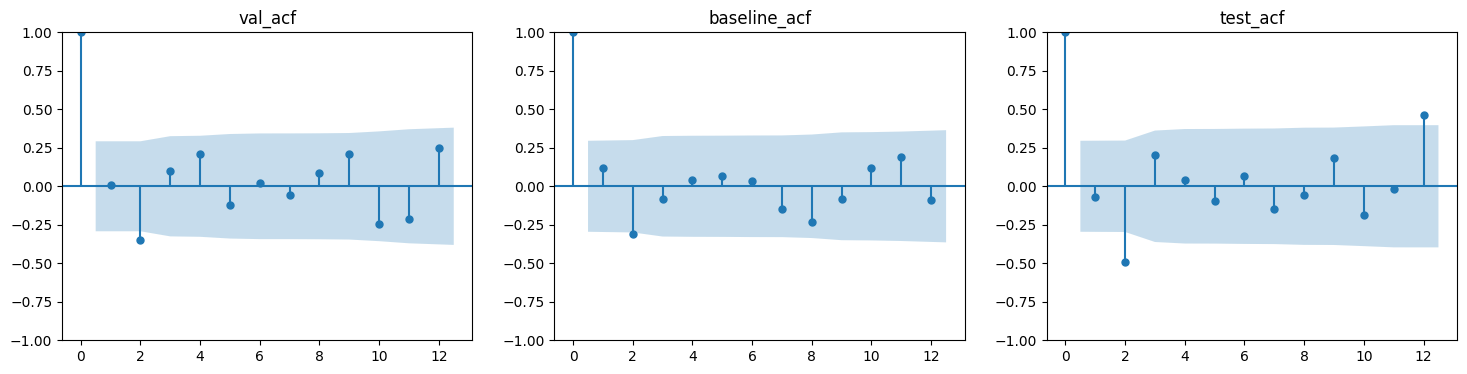

Durbin-Watson — Baseline: 1.753 | Hybrid: 2.046


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

fig, axes = plt.subplots(1,3, figsize= (18, 4))
plot_acf( residual_pred_valf, lags = 12, ax = axes[0], title = 'val_acf' )
plot_acf( test_ml['residuals'], lags = 12, ax = axes[1], title = 'baseline_acf' )
plot_acf(residual_pred_testf, lags=12, ax=axes[2], title='test_acf')

plt.savefig('acf_residuals.png', dpi=150)
plt.show()

# 2. Durbin-Watson statistic (quick scalar check)
dw_baseline = durbin_watson(test_ml['residuals'])
dw_hybrid   = durbin_watson(residual_pred_testf)

print(f"Durbin-Watson — Baseline: {dw_baseline:.3f} | Hybrid: {dw_hybrid:.3f}")
# ~2.0 = no autocorrelation, <1.5 = positive autocorrelation (bad), >2.5 = negative


In [18]:
# xgb.importance(
#   model = xgb1,
#   feature_names = getinfo(xgb1,
#     'sca_lagged_1',
#  'sca_lagged_2',
#  'sca_lagged_3',
#  'sca_lagged_4',
#  'sca_lagged_5',
#  'sca_lagged_6',
#  'sca_lagged_7',
#  'dd_lagged_1',
#  'dd_lagged_2',
#  'dd_lagged_3',
#  'dd_lagged_4',
#  'dd_lagged_5',
#  'dd_lagged_6',
#  'dd_lagged_7',
#  'et_loss_lagged_1',
#  'precipitation_lagged_1',
#  'melt_proxy_1_1',
#  'melt_proxy_1_2',
#  'melt_proxy_2_1',
#  'melt_proxy_2_2',
#  'melt_proxy_1_3',
#  'melt_proxy_1_4',
#  'melt_proxy_1_5',
#  'melt_proxy_1_6',
#  'melt_proxy_1_7',
#  'melt_proxy_2_3',
#  'melt_proxy_2_4',
#  'melt_proxy_2_5',
#  'melt_proxy_2_6',
#  'melt_proxy_2_7',
#  'melt_proxy_3_1',
#  'melt_proxy_3_2',
#  'melt_proxy_3_3',
#  'melt_proxy_3_4',
#  'melt_proxy_3_5',
#  'melt_proxy_3_6',
#  'melt_proxy_3_7',
#  'melt_proxy_4_1',
#  'melt_proxy_4_2',
#  'melt_proxy_4_3',
#  'melt_proxy_4_4',
#  'melt_proxy_4_5',
#  'melt_proxy_4_6',
#  'melt_proxy_4_7',
#  'melt_proxy_5_1',
#  'melt_proxy_5_2',
#  'melt_proxy_5_3',
#  'melt_proxy_5_4',
#  'melt_proxy_5_5',
#  'melt_proxy_5_6',
#  'melt_proxy_5_7',
#  'melt_proxy_6_1',
#  'melt_proxy_6_2',
#  'melt_proxy_6_3',
#  'melt_proxy_6_4',
#  'melt_proxy_6_5',
#  'melt_proxy_6_6',
#  'melt_proxy_6_7',
#  'melt_proxy_7_1',
#  'melt_proxy_7_2',
#  'melt_proxy_7_3',
#  'melt_proxy_7_4',
#  'melt_proxy_7_5',
#  'melt_proxy_7_6',
#  'melt_proxy_7_7'
# ),
#   trees = NULL
# )

In [19]:
# Cell 13 - Create a results DataFrame for plotting (use actual names from this notebook)
# Observed: y_test_true (test ground truth)
# Baseline: y_test_pred (baseline LR predictions on X_test_lagged) -> flatten and align index
# Hybrid_XGB: q_hybrid_testf (final hybrid XGB predictions on test)
# Hybrid_LSTM: no LSTM preds in notebook — fill with NaN to keep the same shape
import plotly.graph_objects as go

baseline_series = pd.Series(y_test_pred.ravel(), index=y_test_true.index, name='Baseline')
xgb_series = pd.Series(q_hybrid_testf, index=y_test_true.index, name='Hybrid_XGB')
lstm_series = pd.Series(np.nan, index=y_test_true.index, name='Hybrid_LSTM')

results_df = pd.DataFrame({
    'Observed': y_test_true,
    'Baseline': baseline_series,
    'Hybrid_XGB': xgb_series,
}, index=y_test_true.index)

# Plot the results
fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Observed'], mode='lines', name='Observed Discharge'))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Baseline'], mode='lines', name='Baseline Model', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=results_df.index, y=results_df['Hybrid_XGB'], mode='lines', name='Hybrid XGBoost Model'))

fig.update_layout(title='Model Prediction Performance on Test Data',
                  xaxis_title='Date',
                  yaxis_title='Discharge (m³/s)',
                  legend_title='Models')
fig.show()

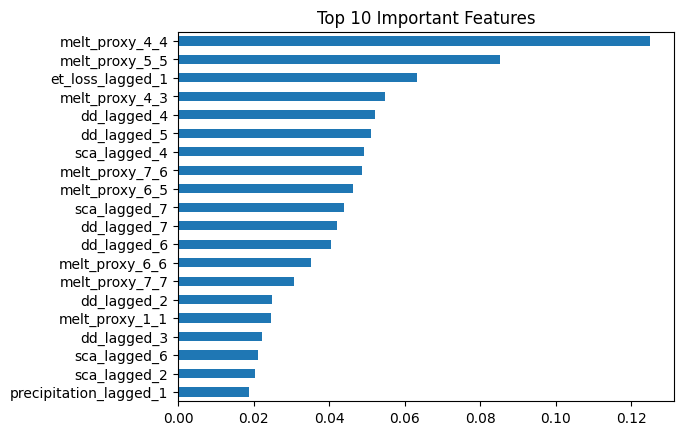

sca_lagged_1              0.016282
dd_lagged_1               0.001995
sca_lagged_2              0.020285
dd_lagged_2               0.024873
sca_lagged_3              0.018171
dd_lagged_3               0.022193
sca_lagged_4              0.049294
dd_lagged_4               0.052123
sca_lagged_5              0.010888
dd_lagged_5               0.050989
sca_lagged_6              0.021184
dd_lagged_6               0.040402
sca_lagged_7              0.044043
dd_lagged_7               0.042055
et_loss_lagged_1          0.063185
precipitation_lagged_1    0.018820
melt_proxy_1_1            0.024559
melt_proxy_2_1            0.008000
melt_proxy_2_2            0.000000
melt_proxy_3_2            0.016091
melt_proxy_3_3            0.017201
melt_proxy_4_3            0.054695
melt_proxy_4_4            0.125116
melt_proxy_5_4            0.011211
melt_proxy_5_5            0.085375
melt_proxy_6_5            0.046319
melt_proxy_6_6            0.035324
melt_proxy_7_6            0.048651
melt_proxy_7_7      

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get scores and match them with feature names
feat_importances = pd.Series(xgb2.feature_importances_, index=X_train_ml.columns)

# 2. Plot the top 10 features
feat_importances.nlargest(20).sort_values().plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()
feat_importances

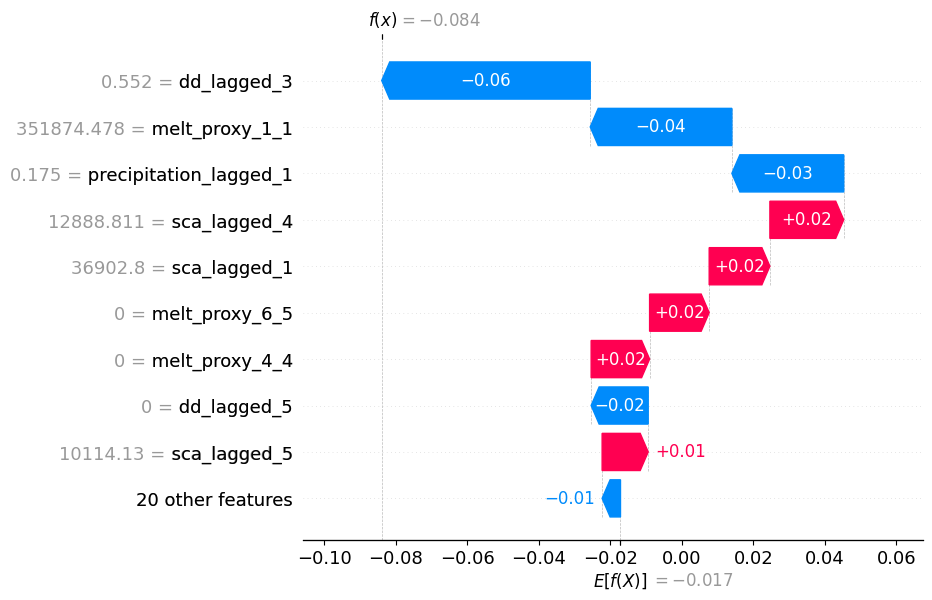

In [21]:
import shap
# Xd = xgboost.DMatrix(X, label=y)

# explainer = shap.TreeExplainer(xgb1)
# explanation = explainer(X_train_ml)
# shap_values = explanation.values
explainer = shap.Explainer(xgb2)
shap_values = explainer(X_train_ml)

shap.plots.waterfall(shap_values[0])


In [22]:
from shap import initjs


initjs()

In [23]:
# visualize the first prediction's explanation with a force plot
shap.plots.force(shap_values[0])

In [24]:
# visualize all the training set predictions
shap.plots.force(shap_values[:500])

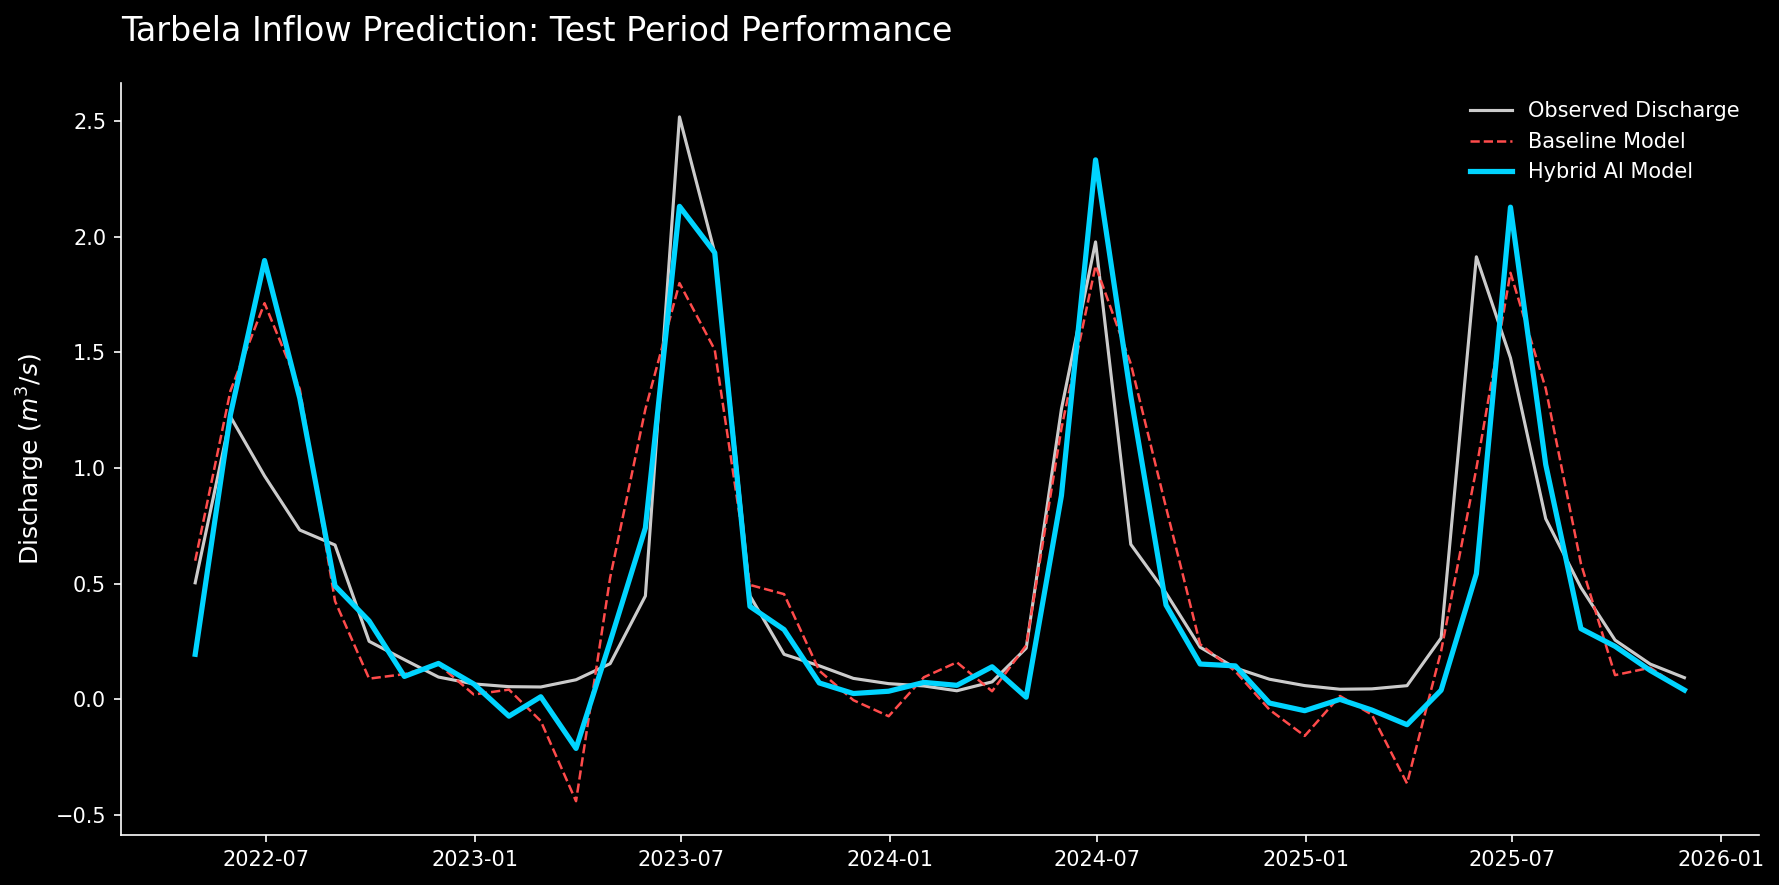

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the dark theme to match your MapLibre UI
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Use the test-series index (ensure datetime) as x-axis.
# df1 does not have a 'date' column because the dataframe was set_index('date') earlier.
date = pd.to_datetime(y_test_true.index)

# Ensure predictions are 1D arrays aligned with the date index
y_test_pred_plot = np.asarray(y_test_pred).ravel()
q_hybrid_plot = np.asarray(q_hybrid_testf).ravel()

# Plotting the three curves
ax.plot(date, y_test_true, label='Observed Discharge', color='#ffffff', linewidth=1.5, alpha=0.8)
ax.plot(date, y_test_pred_plot, label='Baseline Model', color='#ff4b4b', linestyle='--', linewidth=1.2)
ax.plot(date, q_hybrid_plot, label='Hybrid AI Model', color='#00d4ff', linewidth=2.5)

# Highlighting the "Peak Capture"
# You can shade the summer months where the SCA-melt logic is most active
# ax.axvspan('2023-06-01', '2023-08-31', color='#00d4ff', alpha=0.05, label='Peak Melt Season')

# Formatting
ax.set_title('Tarbela Inflow Prediction: Test Period Performance', loc='left', fontsize=16, pad=20)
ax.set_ylabel('Discharge ($m^3/s$)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('hydrograph_performance.png', transparent=True)

In [26]:

# In order of priority:

# Observed vs predicted hydrograph — most important, get this first
# Scatter plot with R² — quick to make once you have predictions exported
# Feature importance bar chart — you have the values already, just needs a clean plot
# Bias correction table — pull your Besham validation numbers

In [40]:
# Verify this:
# ensure the DataFrame index is a DatetimeIndex before using .year
df.index = pd.to_datetime(df.index)

print(df[df.index.year == 2022]['precipitation'].mean())
print(df[df.index.year.isin([2010,2015,2020])]['precipitation'].mean())

# Was 2022 precipitation anomalously low?

1.0857665337411069
1.1983978306716618


In [54]:
# 1. Compare 2022 to 2002 conditions

low_flow_years = df[df.index.year.isin([2002, 2022])]
normal_years = df[df.index.year.isin([2015, 2018])]

print("Low flow years mean precip:", low_flow_years['precipitation'].mean())
print("Normal years mean precip:", normal_years['precipitation'].mean())

# 2. Check SCA (snow cover)
print("2022 max SCA:", df[df.index.year == 2022]['sca'].max())
print("Typical max SCA:", df['sca'].quantile(0.75))

# 3. Residual analysis
df_adv['residual'] = df_adv['baseline_q'] - q_hybrid_testf
print("\n2022 residuals:")
# align baseline and hybrid predictions with the test index and show 2022 rows
baseline_series = pd.Series(y_test_pred.ravel(), index=y_test_true.index, name='Q_pred')
hybrid_series = pd.Series(q_hybrid_testf, index=y_test_true.index, name='Q_hybrid')

df_2022 = pd.DataFrame({
    'Q_obs': y_test_true,
    'Q_pred': baseline_series,
    'Q_hybrid': hybrid_series,
})
df_2022.index = pd.to_datetime(df_2022.index)

df_2022['residual'] = df_2022['Q_obs'] - df_2022['Q_hybrid']

print(df_2022[df_2022.index.year == 2022])

# Are residuals consistently negative (underestimation)?

Low flow years mean precip: 0.9049948718994605
Normal years mean precip: 1.1254712235222837
2022 max SCA: 47013.76978704685
Typical max SCA: 36316.95652535525

2022 residuals:
               Q_obs    Q_pred  Q_hybrid  residual
date                                              
2022-04-30  0.503080  0.598684  0.193718  0.309362
2022-05-31  1.222156  1.334095  1.230845 -0.008689
2022-06-30  0.965498  1.713185  1.897869 -0.932371
2022-07-31  0.731501  1.341833  1.301888 -0.570386
2022-08-31  0.666706  0.423843  0.489791  0.176915
2022-09-30  0.249801  0.088340  0.337937 -0.088136
2022-10-31  0.170489  0.107795  0.097972  0.072517
2022-11-30  0.095213  0.150547  0.154111 -0.058897
2022-12-31  0.065464  0.019689  0.065249  0.000215


In [55]:
# Compare 2022 summer temperatures to other years
summer_2022_dd = df[(df.index >= '2022-06-01') & (df.index <= '2022-08-31')]['dd'].mean()
summer_typical = df[(df.index.month.isin([6,7,8]))]['dd'].mean()

print(f"2022 summer DD: {summer_2022_dd}")
print(f"Typical summer DD: {summer_typical}")

# If 2022 summer was COOLER, that explains it!

2022 summer DD: 0.0
Typical summer DD: 0.0


In [27]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid
# You can expand this grid to tune other parameters as well
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'n_estimators': range(100,1500, 100),
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize the XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
# We use 'neg_root_mean_squared_error' as the scoring metric.
# GridSearchCV maximizes the score, so it minimizes RMSE.
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_root_mean_squared_error')

# Fit GridSearchCV
# Note: This can take some time to run
grid_search.fit(X_train_ml, y_train_ml)

# Print the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")

# You can now use the best estimator for prediction
best_xgb_model = grid_search.best_estimator_

Fitting 3 folds for each of 210 candidates, totalling 630 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=300; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_

LSTM NSE (Test): 0.7289
LSTM R²  (Test): 0.7289


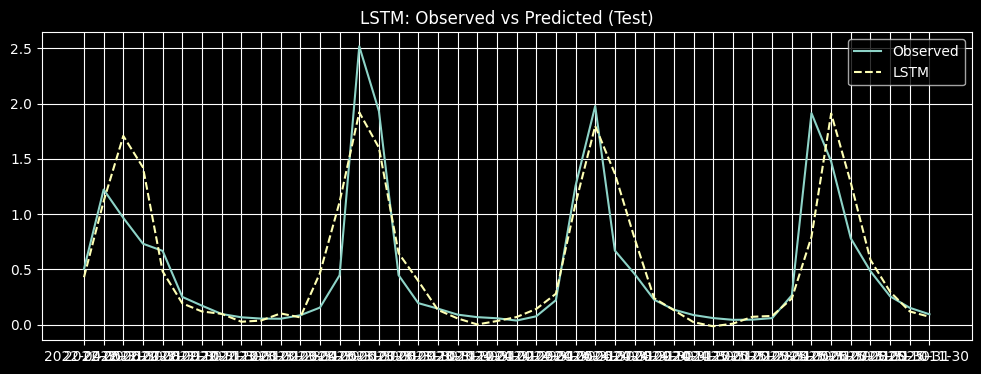

In [38]:
# --- LSTM baseline on the same leakage-free lagged splits ---
# Uses X_train_lagged / X_val_lagged / X_test_lagged and Y_*_lagged created above.

import numpy as np
import pandas as pd

# Try TensorFlow/Keras; if unavailable, fail with a clear error message
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except Exception as e:
    raise ImportError(
        "TensorFlow is required for the LSTM cell. Install it (e.g., `pip install tensorflow`) and rerun."
    ) from e

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1) Scale features based on train only (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lagged)
X_val_scaled = scaler.transform(X_val_lagged)
X_test_scaled = scaler.transform(X_test_lagged)

# 2) Reshape to (samples, timesteps, features)
# Here we treat each row as a 1-timestep sequence (since we already encoded history via lag features)
X_train_seq = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_seq = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_seq = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Targets
y_train = Y_train_lagged['runoff'].values.astype(np.float32)
y_val = Y_val_lagged['runoff'].values.astype(np.float32)
y_test = Y_test_lagged['runoff'].values.astype(np.float32)

# 3) Define a small LSTM (kept intentionally simple to avoid overfitting)
# NOTE: This is a quick diagnostic baseline, not a fully tuned deep model.
tf.keras.utils.set_random_seed(42)

model = models.Sequential([
    layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=1500,
    batch_size=64,
    verbose=0,
    callbacks=callbacks
)

# 4) Evaluate on test
y_pred_test = model.predict(X_test_seq, verbose=0).ravel()

lstm_nse = calculate_nse(y_test, y_pred_test)
lstm_r2 = r2_score(y_test, y_pred_test)

print(f"LSTM NSE (Test): {lstm_nse:.4f}")
print(f"LSTM R²  (Test): {lstm_r2:.4f}")

# Optional quick visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(Y_test_lagged.index, y_test, label='Observed')
plt.plot(Y_test_lagged.index, y_pred_test, label='LSTM', linestyle='--')
plt.title('LSTM: Observed vs Predicted (Test)')
plt.legend()
plt.grid(True)
plt.show()
